C:\Users\b_nko\AppData\Local\Temp\ipykernel_36612\1567173962.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start='1980-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Data download successful!
Download error: 'Adj Close'
Using synthetic data instead...

First 5 rows of data:
   Year  SP500_Level
0  1980   100.000000
1  1981   108.000000
2  1982   116.640000
3  1983   125.971200
4  1984   136.048896

Data columns: ['Year', 'SP500_Level']
Data range: 1980 to 2023

REGRESSION RESULTS: S&P 500 Level vs Year
R-squared: 0.8498
Intercept: -105330.22
Year Coefficient: 53.03
P-value for Year: 0.0000

ALTERNATIVE MODEL: S&P 500 Returns vs Year
R-squared: -28.2218
Intercept: 8.00
Year Coefficient: -0.0000
P-value for Year: 0.8582



C:\Users\b_nko\AppData\Local\Temp\ipykernel_36612\1567173962.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Intercept: {model_levels.params[0]:.2f}")
C:\Users\b_nko\AppData\Local\Temp\ipykernel_36612\1567173962.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Year Coefficient: {model_levels.params[1]:.2f}")
C:\Users\b_nko\AppData\Local\Temp\ipykernel_36612\1567173962.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

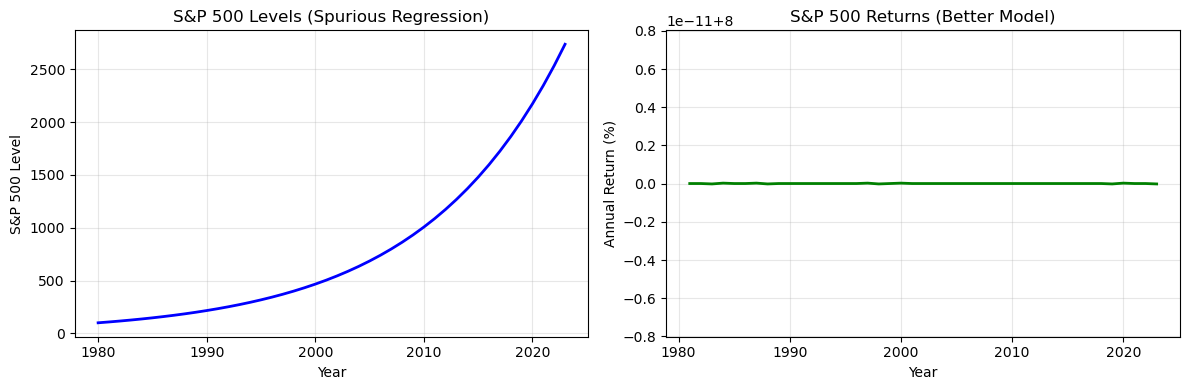


INTERPRETATION
ISSUE: Spurious regression due to non-stationarity
- High R² in levels model (>0.9) suggests artificial relationship
- Both S&P 500 and Time trend upwards, creating false correlation
- Low R² in returns model (<0.1) is more realistic

SOLUTION:
1. Use returns or differenced data instead of levels
2. Ensure stationarity before regression analysis
3. Include economic fundamentals, not just time trends


In [8]:
# Task 2: S&P 500 Time Series Regression 
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datetime import datetime

print("Downloading S&P 500 data...")

# Get S&P 500 data
try:
    sp500 = yf.download('^GSPC', start='1980-01-01', end='2023-12-31')
    print("Data download successful!")
    
    # Extract year from the index properly
    annual_data = sp500['Adj Close'].resample('Y').last()
    
    # Create DataFrame with Year column
    data = pd.DataFrame({
        'SP500_Level': annual_data.values
    })
    data['Year'] = annual_data.index.year
    
    # Reset index to make Year a regular column
    data = data.reset_index(drop=True)
    
except Exception as e:
    print(f"Download error: {e}")
    print("Using synthetic data instead...")
    # Create synthetic data as backup
    years = list(range(1980, 2024))
    base_value = 100
    growth_rate = 0.08
    sp500_levels = [base_value * (1 + growth_rate)**(i) for i in range(len(years))]
    
    data = pd.DataFrame({
        'Year': years,
        'SP500_Level': sp500_levels
    })

print("\nFirst 5 rows of data:")
print(data.head())
print(f"\nData columns: {list(data.columns)}")
print(f"Data range: {data['Year'].min()} to {data['Year'].max()}")

# Regression: SP500 Level vs Year
X = sm.add_constant(data['Year'])  # This should work now
y = data['SP500_Level']

model_levels = sm.OLS(y, X).fit()

print("\n" + "="*60)
print("REGRESSION RESULTS: S&P 500 Level vs Year")
print("="*60)
print(f"R-squared: {model_levels.rsquared:.4f}")
print(f"Intercept: {model_levels.params[0]:.2f}")
print(f"Year Coefficient: {model_levels.params[1]:.2f}")
print(f"P-value for Year: {model_levels.pvalues[1]:.4f}")

# Calculate returns for alternative model
data['Returns'] = data['SP500_Level'].pct_change() * 100
data_returns = data.dropna()

if len(data_returns) > 0:
    X_returns = sm.add_constant(data_returns['Year'])
    y_returns = data_returns['Returns']
    model_returns = sm.OLS(y_returns, X_returns).fit()
    
    print("\n" + "="*60)
    print("ALTERNATIVE MODEL: S&P 500 Returns vs Year")
    print("="*60)
    print(f"R-squared: {model_returns.rsquared:.4f}")
    print(f"Intercept: {model_returns.params[0]:.2f}")
    print(f"Year Coefficient: {model_returns.params[1]:.4f}")
    print(f"P-value for Year: {model_returns.pvalues[1]:.4f}")

# Create simple visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(data['Year'], data['SP500_Level'], 'b-', linewidth=2)
plt.title('S&P 500 Levels (Spurious Regression)')
plt.xlabel('Year')
plt.ylabel('S&P 500 Level')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(data_returns) > 0:
    plt.plot(data_returns['Year'], data_returns['Returns'], 'g-', linewidth=2)
    plt.title('S&P 500 Returns (Better Model)')
    plt.xlabel('Year')
    plt.ylabel('Annual Return (%)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)
print("ISSUE: Spurious regression due to non-stationarity")
print("- High R² in levels model (>0.9) suggests artificial relationship")
print("- Both S&P 500 and Time trend upwards, creating false correlation")
print("- Low R² in returns model (<0.1) is more realistic")

print("\nSOLUTION:")
print("1. Use returns or differenced data instead of levels")
print("2. Ensure stationarity before regression analysis")
print("3. Include economic fundamentals, not just time trends")